In [26]:
import tensorflow as tf
import os
import random
import numpy as np

# confirm GPU is available
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [27]:
SEED = 123456
os.environ['PYTHONHASHSEED']=str(SEED)
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'  # new flag present in tf 2.0+
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [28]:
from tensorflow.keras.datasets import fashion_mnist


(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
assert x_train.shape == (60000, 28, 28)
assert x_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)

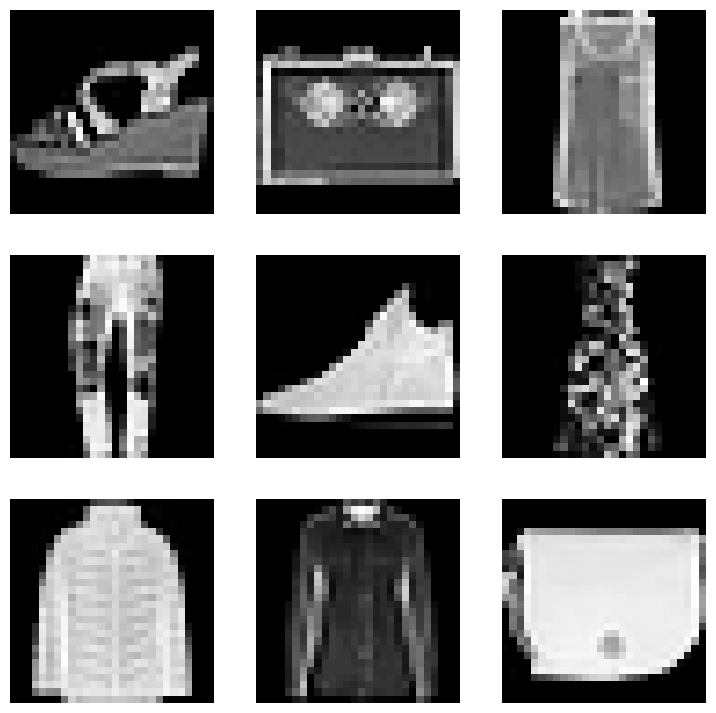

In [29]:
import numpy as np
from matplotlib import pyplot as plt

plt.figure(figsize=(9, 9))

# Choose 9 samples out of 60K available in the train set
rndSamples = np.random.choice(60000, 9)

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[rndSamples[i]], cmap="Greys_r")
    plt.axis('off')

plt.show();


In [30]:
dataset = np.concatenate([x_train, x_test], axis=0)
# Please note expand_dims converts images from 28x28 to 28x28x1
# Since convolutional layers expect 3 channels
dataset = np.expand_dims(dataset, -1).astype("float32") / 255

In [31]:
from tensorflow import keras
from tensorflow.keras import layers


# Create a sampling layer
class SamplingLayer(layers.Layer):
  """Reparameterization Trick z = mu + sigma * epsilon"""

  def call(self, inputs):
    zMean, zLogVar = inputs
    batch = tf.shape(zMean)[0]
    dim = tf.shape(zMean)[1]
    epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
    return zMean + tf.exp(0.5 * zLogVar) * epsilon

In [33]:
def buildEncoder(latentDim, encoderInputs):

  # Given a batch of images the convolutional block extracts the features
  l1 = keras.models.Sequential([
    layers.Conv2D(128, 3, activation="relu", strides=2, padding="same"),
    layers.Conv2D(64, 3, activation="relu", strides=2, padding="same"),
    layers.Flatten(),
    layers.Dense(256, activation="relu")
  ])

  # pass the inputs through the convolutional block
  x = l1(encoderInputs)

  # a dedicated layer to learn mean in parallel
  zMean = layers.Dense(latentDim, name="z_mean")(x)

  # a dedicated layer to learn variance in parallel
  zLogVar = layers.Dense(latentDim, name="z_log_var")(x)

  # now the reparametrization trick to find z as defined by mean and variance
  z = SamplingLayer()([zMean, zLogVar])

  # the actual model which takes the images as input and returns mean, variance, and distribution
  # please note the zMean and zLogVar are not the final output of the encoder, but
  # they are used in the Kullback-Leibler Divergence Loss (explained below)
  return keras.Model(encoderInputs, [zMean, zLogVar, z], name="encoder")


# trigger the function to actually build the model
encoderInputs = keras.Input(shape=(28, 28, 1))
encoder = buildEncoder(2, encoderInputs)
encoder.summary()

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 28, 28, 1)]          0         []                            
                                                                                                  
 sequential_2 (Sequential)   (None, 256)                  878144    ['input_3[0][0]']             
                                                                                                  
 z_mean (Dense)              (None, 2)                    514       ['sequential_2[0][0]']        
                                                                                                  
 z_log_var (Dense)           (None, 2)                    514       ['sequential_2[0][0]']        
                                                                                            

In [34]:
def buildDecoder(latentInputs):

  l1 = keras.models.Sequential([
    layers.Dense(7*7*64, activation="relu", input_shape=(latentInputs.shape[1],)),
    layers.Reshape((7,7,64)),
    layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same"),
    layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same"),
    layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")
  ])

  return keras.Model(latentInputs, l1(latentInputs), name="decoder")

# build the actual model
latentInputs = keras.Input(shape=(2,))
decoder = buildDecoder(latentInputs)
decoder.summary()


Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 2)]               0         
                                                                 
 sequential_3 (Sequential)   (None, 28, 28, 1)         157633    
                                                                 
Total params: 157633 (615.75 KB)
Trainable params: 157633 (615.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


# Loss Functions
VAE has 2 loss functions! First is the recostruction loss, which penalizes images that are not similar to the orginal images

In [35]:
def reconstructionLoss(data, reconstructed):
  return tf.reduce_mean(
      tf.reduce_sum(
          keras.losses.binary_crossentropy(data, reconstructed),
          axis=(1, 2)
      )
  )
    

Next we have the Kullback-Liebler Divergence loss function, also called Earth mover loss from the analogy of figuring
out how much dirt needs to be moved to transform the shape of the UK to the shape of the US.

What it really does is measure the distance between two probability distributions. It penalizes the model of it learns
a pprobabilty distribution "z" that is diffrenet from the original probability distribution of the data X.

Mathematically it is the same thing as cross entropy - entropy, which mean it works. well for back propagation and log
likelyhood minimization.

In [36]:
def klDivergenceLoss(zMean, zLogVar):
  return tf.reduce_mean(
      tf.reduce_sum(
          -0.5 * (1 + zLogVar - tf.square(zMean) - tf.exp(zLogVar)),
          axis=1
      )
  )

So now we will combine these to total loss function, which just weights them and sum them up. Think of that 
weight(alpha) as another hyperparameter you can tune


In [37]:
def calcTotalLoss(data, reconstructed, zMean, zLogVar):
  loss1 = reconstructionLoss(data, reconstructed)
  loss2 = klDivergenceLoss(zMean, zLogVar)
  klWeight = 3.0
  return  loss1, loss2, loss1 + klWeight * loss2
    

# Overridding train step
Since we are using custom loss function on Mu and sigma, we need to override how the loss is calculated. 
We need to compare X_original and X_reconstructed at the same time while calculating the Kullback-Liebler(KL) loss.

In [38]:
class VAE(keras.Model):
  def __init__(self, encoder, decoder, **kwargs):
    super(VAE, self).__init__(**kwargs)
    self.encoder = encoder
    self.decoder = decoder
    # register total loss as an observable metric in the model training history
    self.totalLossTracker = keras.metrics.Mean(name="total_loss")
    self.ceLossTracker = keras.metrics.Mean(name="ce_loss")
    self.klLossTracker = keras.metrics.Mean(name="kl_loss")
    
  # This are all observable metrics 
  @property
  def metrics(self):
    return [
        self.totalLossTracker,
        self.ceLossTracker,
        self.klLossTracker
    ]

  # Now calculate loss + calculate gradients + update weights
  def train_step(self, data):
    # Gradient tape is a recording of all gradients for the trainable 
    # weights that need to be updated
    with tf.GradientTape() as tape:
        # forward path
        zMean, zLogVar, z = self.encoder(data)
        reconstruction = self.decoder(z)
        ceLoss, klLoss, totalLoss = calcTotalLoss(data, reconstruction, zMean, zLogVar)
    # backward path
    grads = tape.gradient(totalLoss, self.trainable_weights)
    self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

    # keep track of loss
    self.totalLossTracker.update_state(totalLoss)
    self.ceLossTracker.update_state(ceLoss)
    self.klLossTracker.update_state(klLoss)

    # return the loss for history object
    return {
        "total_loss": self.totalLossTracker.result(),
        "ce_loss": self.ceLossTracker.result(),
        "kl_loss": self.klLossTracker.result()
    }

# Train the VAE!

In [39]:
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.legacy.Adam(learning_rate=0.001))
history = vae.fit(dataset, epochs=32, batch_size=128)

Epoch 1/32


2023-09-02 22:13:59.100716: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


547/547 [==============================] - 12s 16ms/step - total_loss: 347.0572 - ce_loss: 322.1195 - kl_loss: 8.3125
Epoch 2/32
547/547 [==============================] - 8s 15ms/step - total_loss: 4975768.0000 - ce_loss: 953.2762 - kl_loss: 1658269.1250
Epoch 3/32
547/547 [==============================] - 8s 15ms/step - total_loss: 725.6592 - ce_loss: 328.6750 - kl_loss: 132.3278
Epoch 4/32
547/547 [==============================] - 8s 15ms/step - total_loss: 479.8958 - ce_loss: 311.3668 - kl_loss: 56.1763
Epoch 5/32
547/547 [==============================] - 8s 15ms/step - total_loss: 469.7167 - ce_loss: 306.0740 - kl_loss: 54.5476
Epoch 6/32
547/547 [==============================] - 9s 16ms/step - total_loss: 457.7696 - ce_loss: 301.6940 - kl_loss: 52.0253
Epoch 7/32
547/547 [==============================] - 9s 16ms/step - total_loss: 418.8410 - ce_loss: 299.5220 - kl_loss: 39.7730
Epoch 8/32
547/547 [==============================] - 9s 16ms/step - total_loss: 402.0520 - ce_los

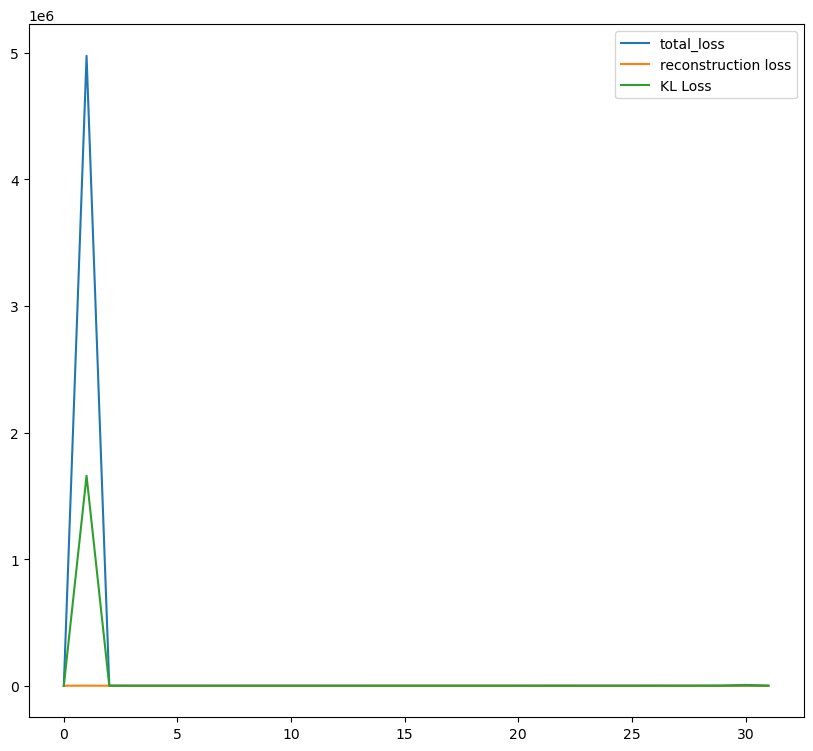

In [42]:
#lets visualize how the loss functions changed over each epoch;this can inform at what point it make sense to stop
plt.figure(figsize=(10,9))
plt.plot(history.history.get('total_loss'), label='total_loss')
plt.plot(history.history.get('ce_loss'), label='reconstruction loss')
plt.plot(history.history.get('kl_loss'), label='KL Loss')
plt.legend()


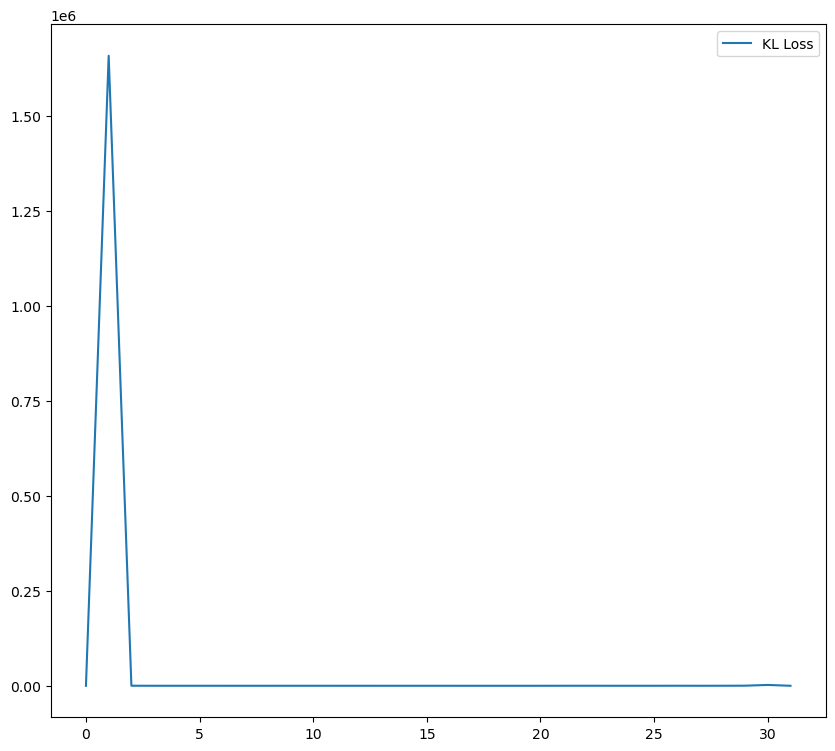

In [43]:
#let's zoom into KL loss so we can see it better
plt.figure(figsize=(10,9))
plt.plot(history.history.get('kl_loss'), label='KL Loss')
plt.legend()

2023-09-03 21:27:55.993807: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 0s 450ms/step


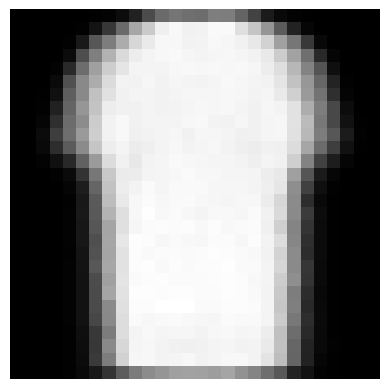

In [45]:
#lets use a mean(mu) of 1 and variance (sigma) of 2 (just a guess to start with). play around with this , try diffrent 
#values to get different type of objects (shirts, bags, etc)

synth = vae.decoder.predict([[1,2]])
plt.axis('off')
plt.imshow(synth.reshape((28,28)), cmap="Greys_r")

Lets generate 256 images entirely at random. All we have to do is guess the Z distribution (defined by mu, sigma). 
Don't worry we will get to a systematic method to determine the mu and sigma for each categorym

8/8 [==============================] - 0s 4ms/step


2023-09-03 21:41:31.092089: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


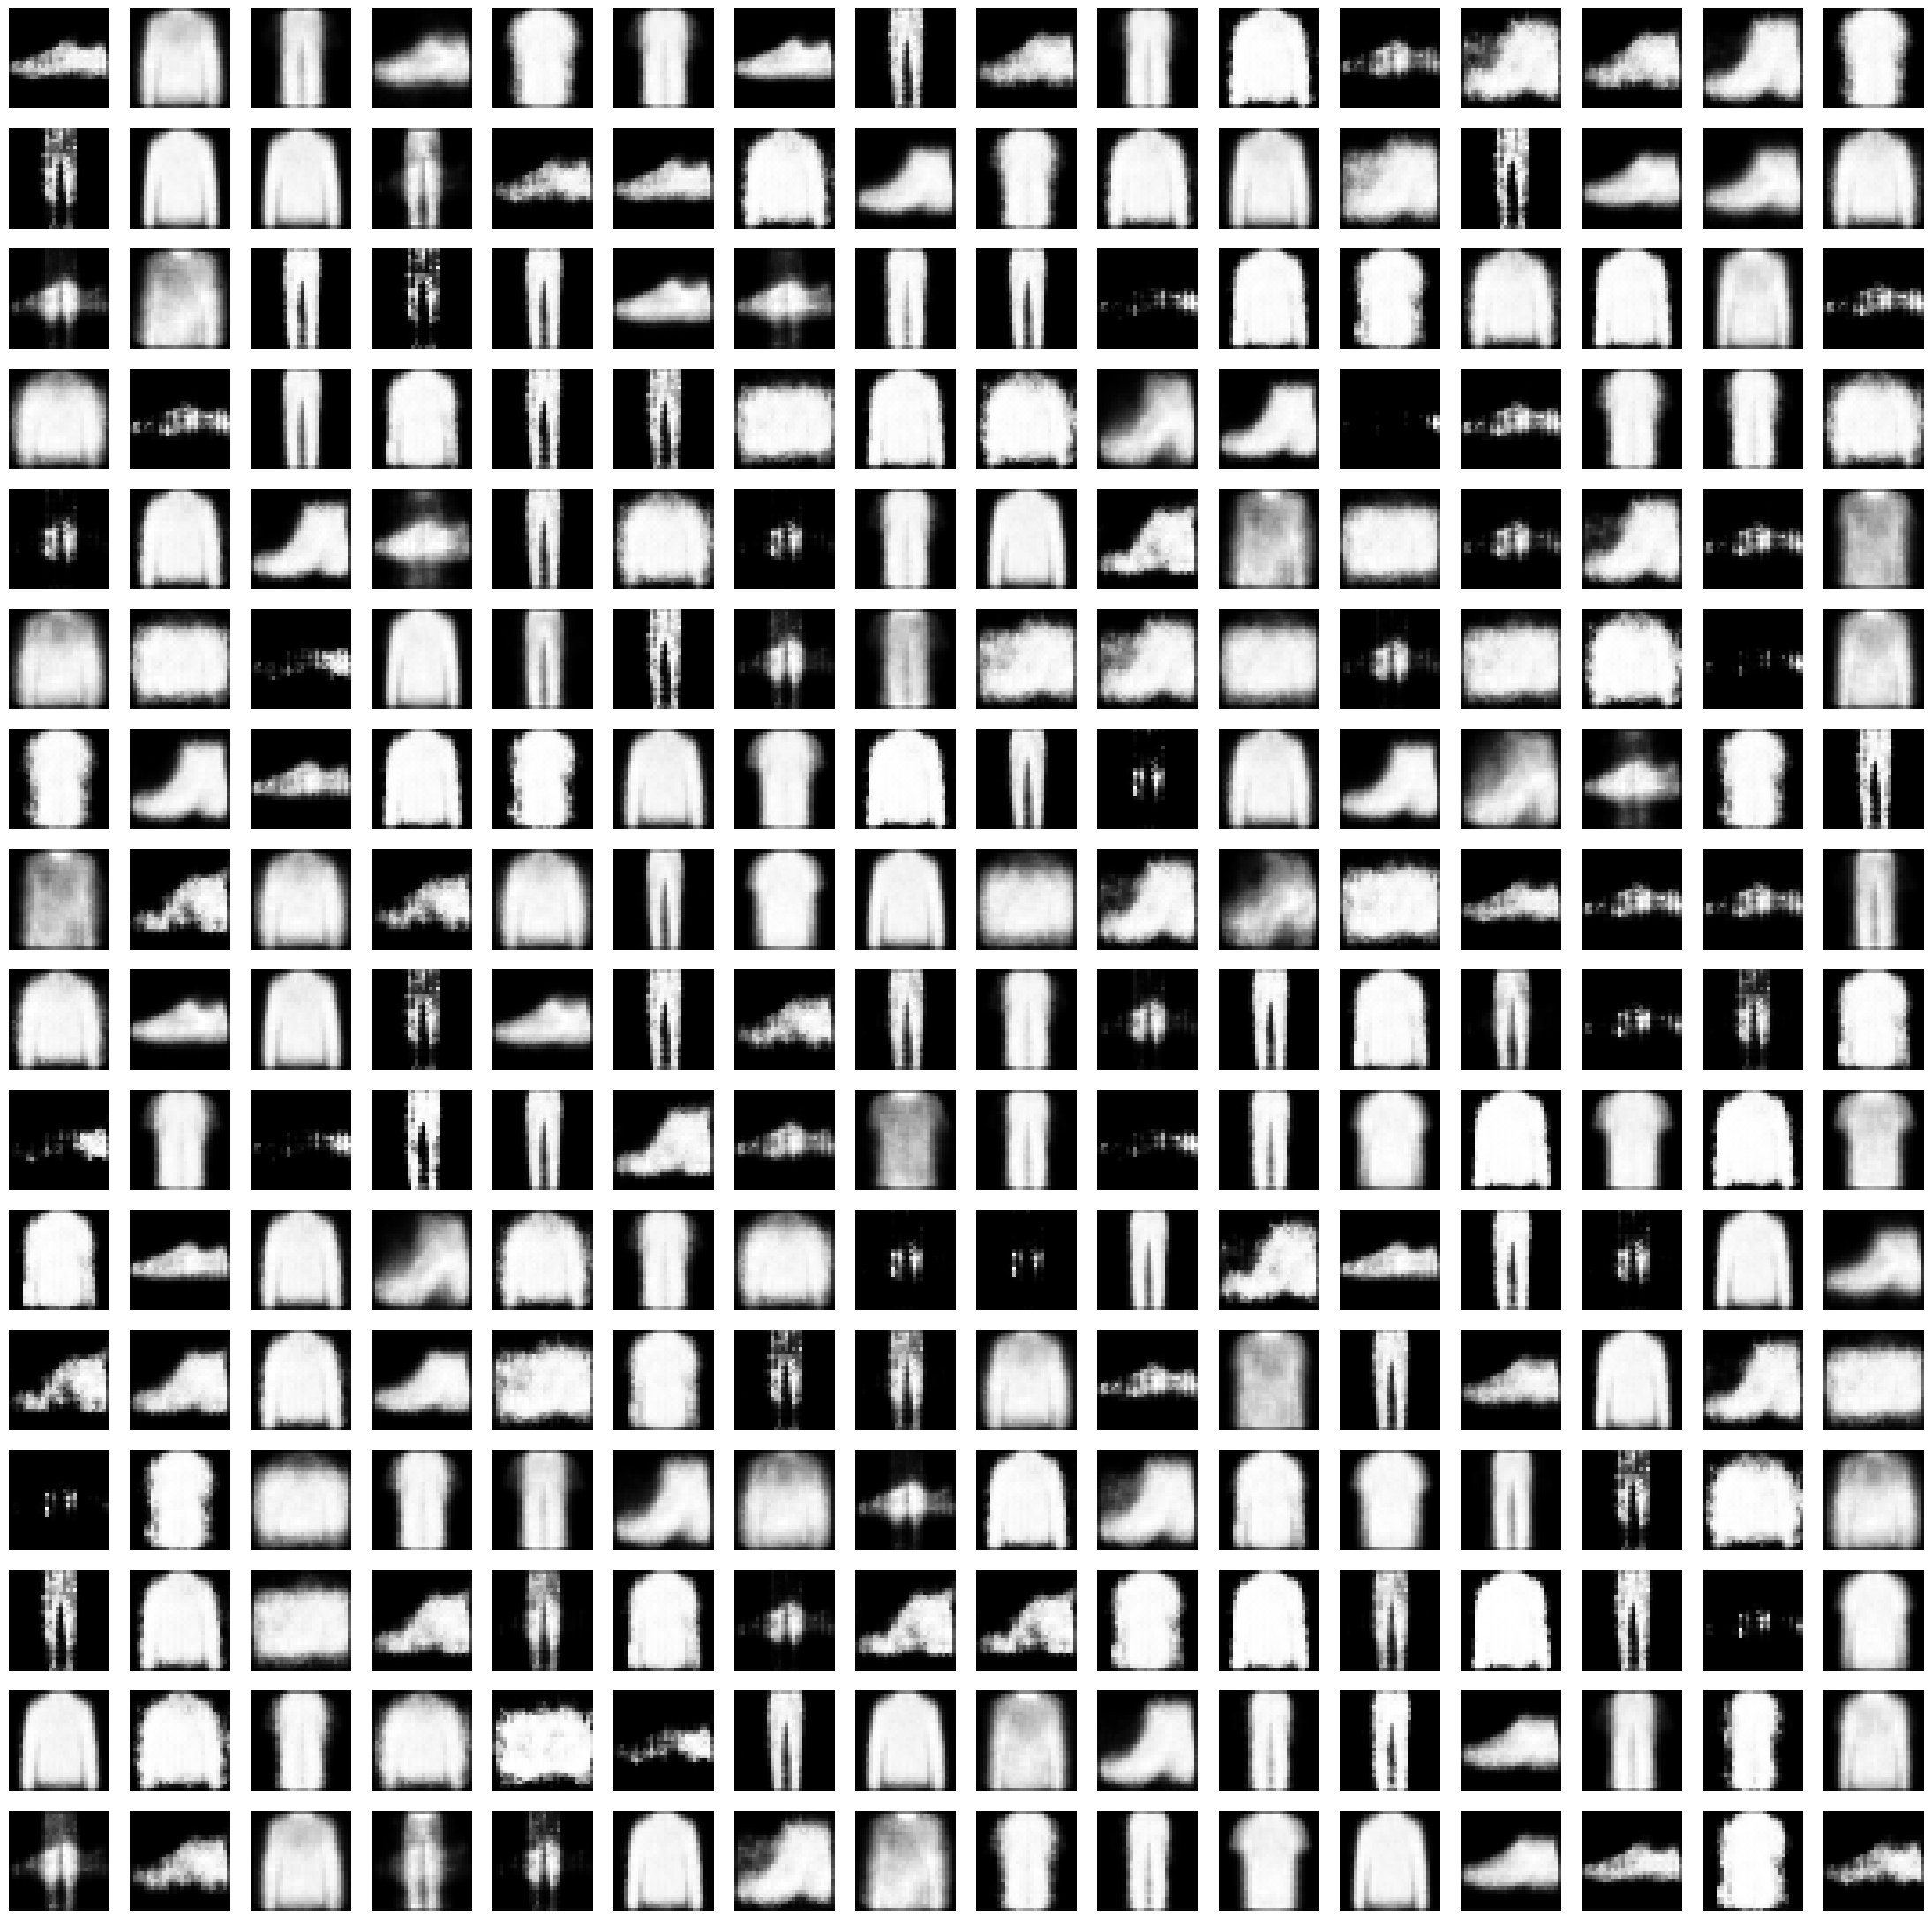

In [47]:
z= np.random.normal(loc=0, scale=4, size=(256, 2))
synth = vae.decoder.predict(z)

plt.figure(figsize=(28,28))
for i in range(256):
    plt.subplot(16, 16, i+1)
    plt.imshow(synth[i].reshape((28,28)), cmap='Greys_r')
    plt.axis('off')
    
plt.show()

As promised, we can find the mapping of mu and sigma for each category. Just map an image of each category through the
encoder and observe the output. Then use those outputs to conditionaly instruct the decoder to sample from a 
particular category. This is not a guranteed solution though, for concrete results lookup "Conditional Variational 
AutoEncoders"

In [48]:
idx = 1280
batch = np.expand_dims(x_train[idx], axis=0)
batchOfImages = np.expand_dims(batch, axis=-1).astype("float32") / 255
print(batchOfImages.shape)
# obtain z (mu, sigma) for the given image
_, _, z = vae.encoder.predict(batchOfImages)

# now reconstruct a similar image
synth = vae.decoder.predict(z)
z

(1, 28, 28, 1)


2023-09-03 21:50:10.852748: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 0s 47ms/step


2023-09-03 21:50:11.258854: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


array([[-0.7540328,  2.5247185]], dtype=float32)

Note that the reconstructed image could be different from the original, depending on how long the model has been 
trained and wether it has reached the global minima.

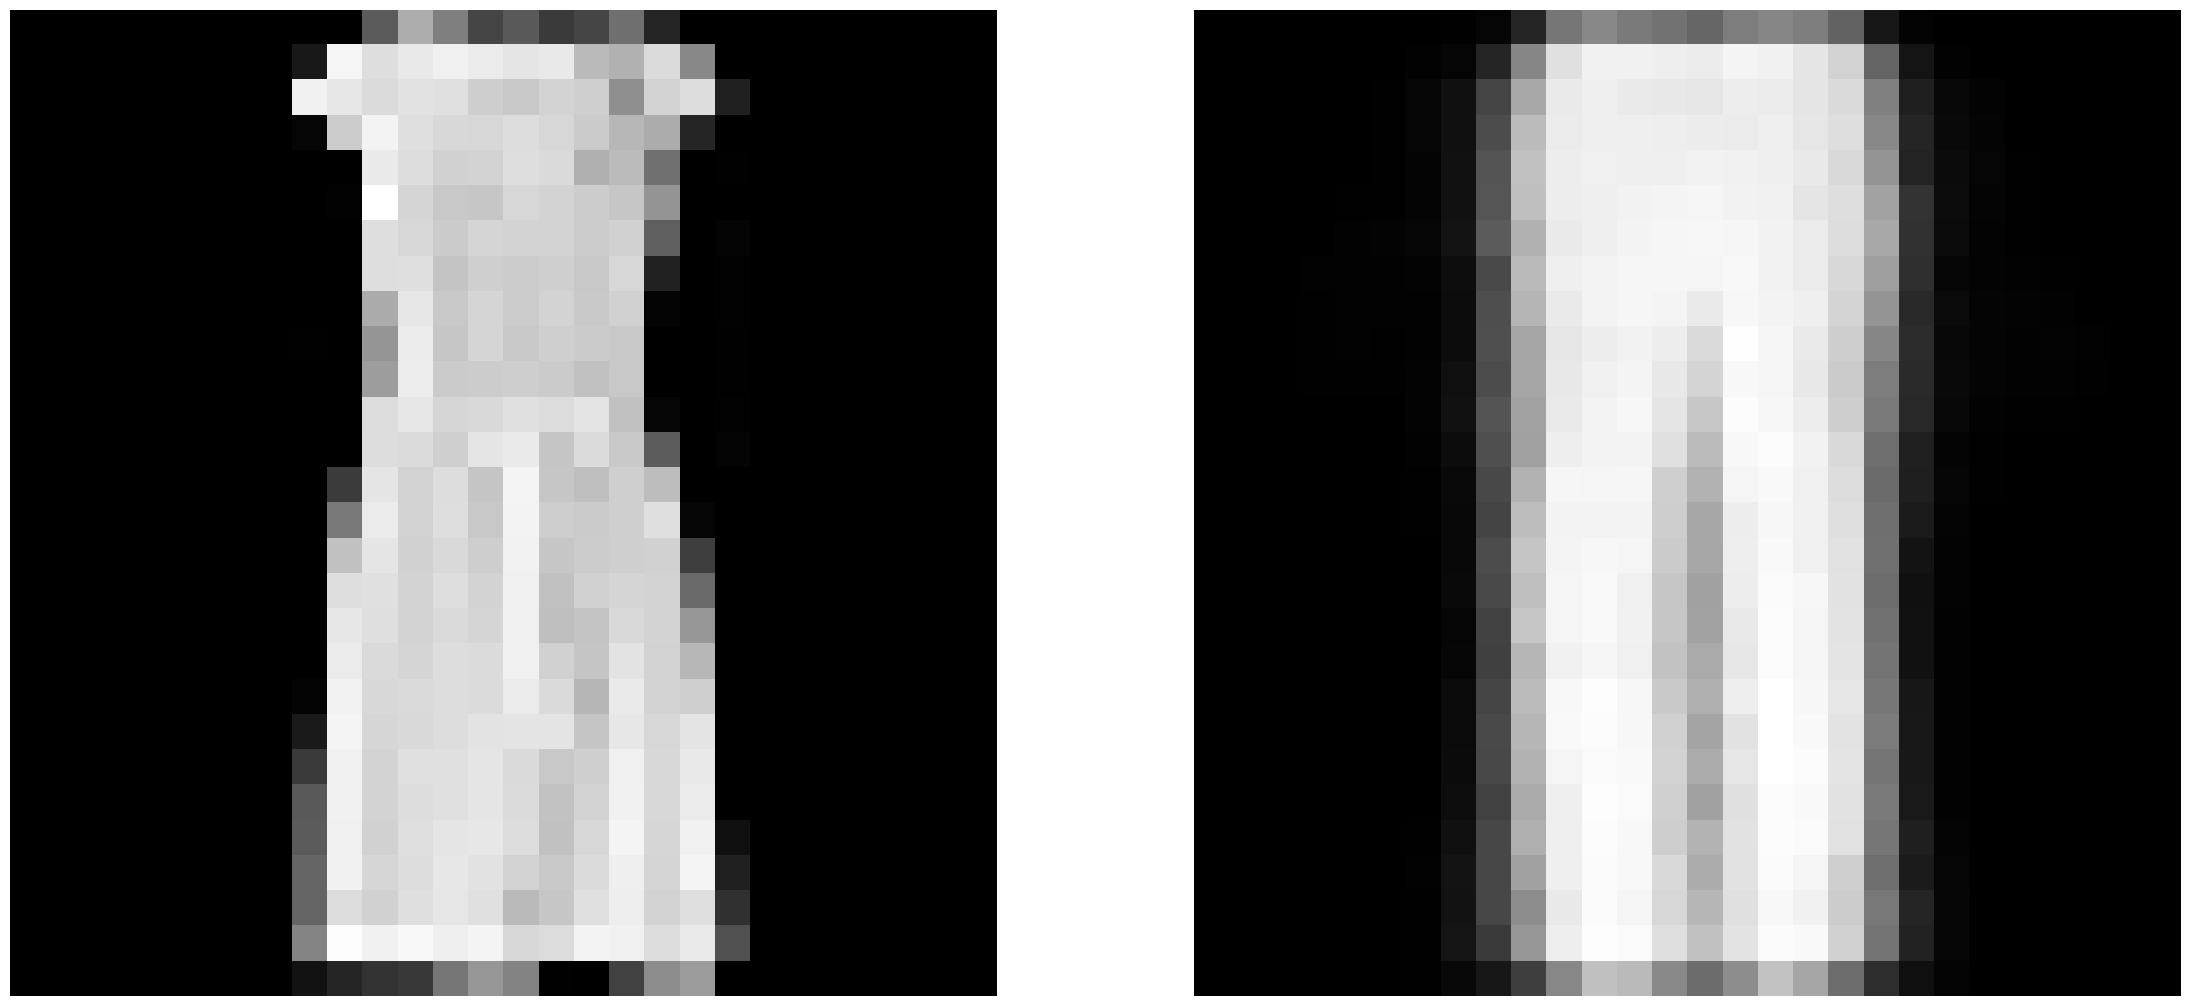

In [49]:
plt.figure(figsize=(28,28))

## original image
plt.subplot(1,2,1)
plt.axis('off')
plt.imshow(x_train[idx], cmap='Greys_r')

#reconstructed
plt.subplot(1,2,2)
plt.axis('off')
plt.imshow(synth[0].reshape((28,28)), cmap='Greys_r')
plt.show()

2188/2188 [==============================] - 3s 1ms/step


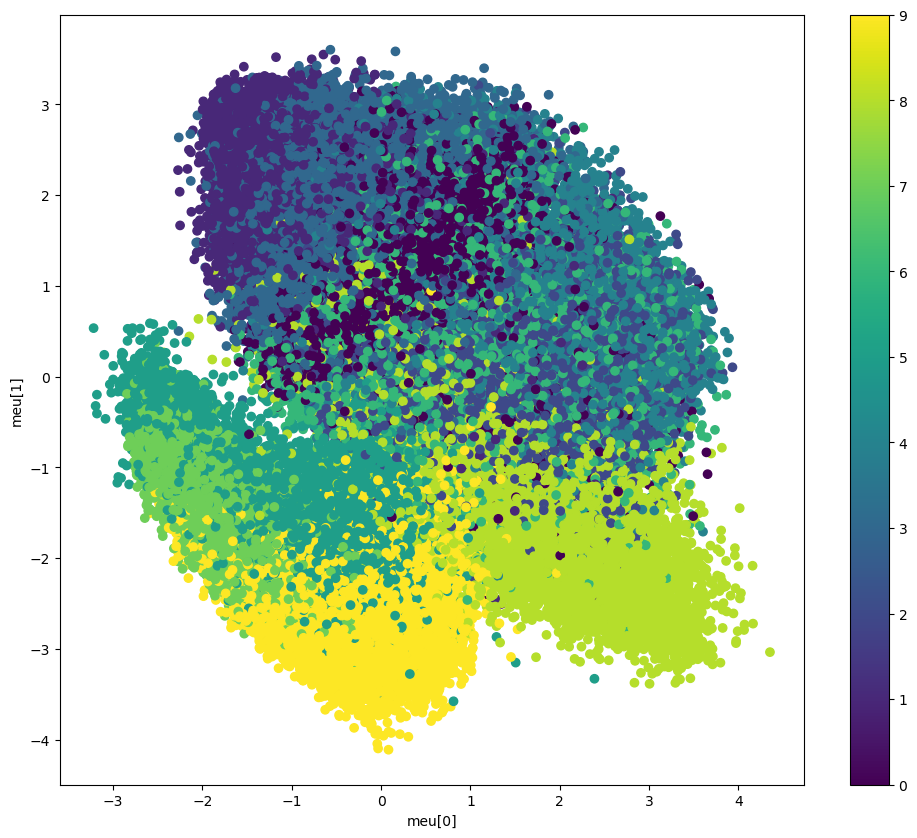

In [51]:
"""
VAE can be used in unsupervised learning of large text or unlabeled image corpus to cluster the sample into
categories
"""
labels = np.concatenate([y_train, y_test], axis=0)
meu, _, _ = vae.encoder.predict(dataset)
plt.figure(figsize=(12,10))
plt.scatter(meu[:, 0], meu[:, 1], c=labels)
plt.colorbar()
plt.xlabel("meu[0]")
plt.ylabel("meu[1]")
plt.show()